# Notebook 1 — Introduction to Graph Theory

## Why Graphs? Why Now?

Your brain contains approximately **86 billion neurons**. Each neuron connects to hundreds or thousands of others, forming roughly **100 trillion synaptic connections**. These connections are not random—they are organized, sparse, and structured. Understanding how to describe, measure, and generate such networks requires a mathematical language.

That language is **graph theory**.

A graph is simply a collection of nodes (in neuroscience, neurons) connected by edges (synapses). Graph theory gives us tools to ask questions like:
- How clustered is this network? (Do neighbors of a neuron tend to be neighbors of each other?)
- How long is the shortest path between two neurons? (How many synaptic steps apart are they?)
- How does the network's structure support its function? (Is it organized hierarchically? Modularly?)
- Can we generate networks with these properties artificially?

This notebook is the **foundation for everything that follows**. We'll introduce the basic concepts of graph theory, motivated throughout by biological examples. By the end, you'll understand the language we'll use to explore neural networks mathematically.

### The Series Overview

You're working through a 7-notebook series on biologically inspired graph networks:

1. **Notebook 1 — Introduction to Graph Theory** (this notebook): Foundational concepts, terminology, and visual examples
2. **Notebook 2 — Analyzing Graph Features**: Metrics that characterize networks (clustering, path length, degree distribution)
3. **Notebook 3 — Generating Sparse Networks (Techniques)**: Classical methods (Erdős-Rényi, Watts-Strogatz, Barabási-Albert, spatial graphs)
4. **Notebook 4 — Generating Biologically Inspired Graphs (Methods)**: Hybrid approaches combining multiple mechanisms
5. **Notebook 5 — Generating Graphs Using Pruning**: The over-build-then-prune developmental principle
6. **Notebook 6 — Multiple Pruning Events**: Iterative refinement and long-term development
7. **Notebook 7 — Functional Cluster Analysis**: Analyzing and visualizing network communities

By Notebook 7, you'll be able to generate, analyze, and understand networks that mimic biological neural systems.

---

## Setup and Imports

We'll use three main libraries throughout this series:
- **NetworkX**: For creating and analyzing graphs
- **NumPy**: For numerical computation
- **Matplotlib**: For visualization

Let's import them and verify everything is working:

In [2]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

# Set a seed for reproducible visualizations
np.random.seed(42)

print("Imports successful. Ready to explore graph theory.")

Imports successful. Ready to explore graph theory.


---

## What is Graph Theory?

Graph theory is a branch of mathematics and computer science that studies the properties of **graphs**. At its heart, a graph is simple:

- **Nodes** (also called vertices): Objects or entities (in neuroscience, neurons)
- **Edges** (also called arcs): Connections between pairs of nodes (in neuroscience, synapses)

Graphs are used to model relationships between entities, and they appear everywhere: social networks (people are nodes, friendships are edges), the internet (computers are nodes, data links are edges), transportation networks (cities are nodes, roads are edges), and biological systems (cells, neurons, proteins).

The concept of a graph was first introduced in the 18th century by Swiss mathematician Leonhard Euler, who used it to solve the famous "Seven Bridges of Königsberg" problem. Since then, graph theory has evolved into a rich and fundamental area of mathematics, with deep applications across science and engineering.

### Biological Motivation

Why does this matter for neuroscience? Because the brain **is a graph**. Neural circuits are networks of neurons connected by synapses. The structure of this network—which neurons connect to which, with what strengths, in what patterns—directly determines the brain's computational capabilities. Graph theory gives us the mathematical tools to describe, measure, and generate these structures.

---

## Types of Graphs

Graphs come in several varieties, depending on the relationships they represent.

### Undirected vs. Directed Graphs

In an **undirected graph**, edges have no direction. The edge between nodes A and B is the same as the edge between B and A. Think of a friendship: if Alice is friends with Bob, then Bob is friends with Alice. The relationship is symmetric.

In a **directed graph** (or **digraph**), edges have a direction indicated by arrows. An edge goes *from* one node *to* another. Think of following someone on Twitter: you might follow them, but they might not follow you back. The relationship is asymmetric.

**In neuroscience:**
- **Undirected graphs** can model functional connectivity: "These neurons fire together, suggesting they're correlated." Correlation doesn't imply direction.
- **Directed graphs** model synaptic connectivity: "Neuron A makes a synapse onto neuron B." Information flows in one direction (from presynaptic to postsynaptic neuron).

Most of this series focuses on directed graphs (which are more biologically accurate), but we start with undirected graphs for simplicity.

Let's visualize both:

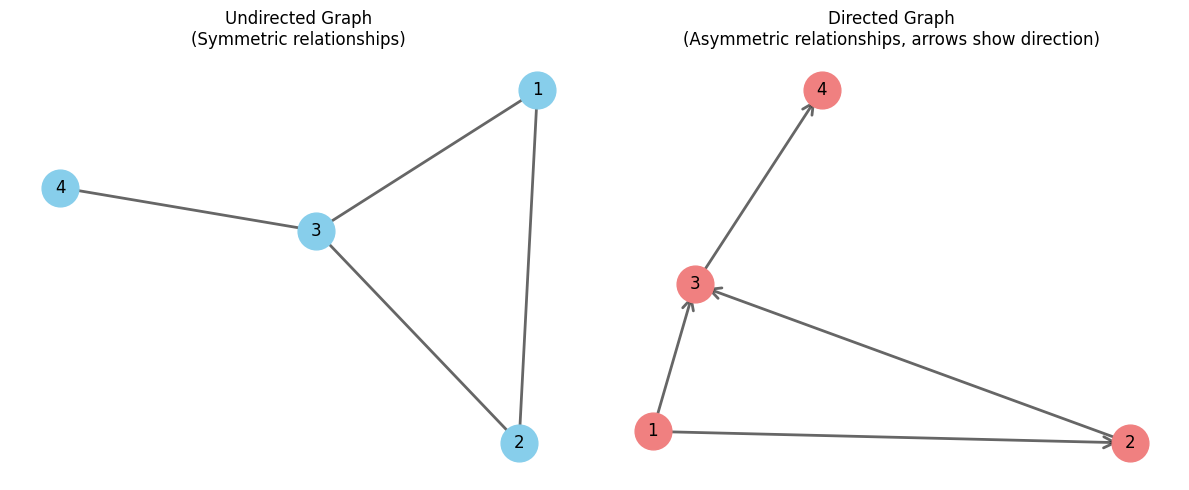

In [3]:
# Create an undirected graph
G_undirected = nx.Graph()
G_undirected.add_edges_from([(1, 2), (2, 3), (3, 1), (3, 4)])

# Create a directed graph
G_directed = nx.DiGraph()
G_directed.add_edges_from([(1, 2), (2, 3), (1, 3), (3, 4)])

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Undirected
pos_undirected = nx.spring_layout(G_undirected, seed=42)
nx.draw_networkx_nodes(G_undirected, pos_undirected, node_color='skyblue', node_size=700, ax=axes[0])
nx.draw_networkx_edges(G_undirected, pos_undirected, ax=axes[0], width=2, alpha=0.6)
nx.draw_networkx_labels(G_undirected, pos_undirected, font_size=12, ax=axes[0])
axes[0].set_title("Undirected Graph\n(Symmetric relationships)")
axes[0].axis('off')

# Directed
pos_directed = nx.spring_layout(G_directed, seed=42)
nx.draw_networkx_nodes(G_directed, pos_directed, node_color='lightcoral', node_size=700, ax=axes[1])
nx.draw_networkx_edges(G_directed, pos_directed, ax=axes[1], width=2, alpha=0.6, arrows=True, arrowsize=20, arrowstyle='->')
nx.draw_networkx_labels(G_directed, pos_directed, font_size=12, ax=axes[1])
axes[1].set_title("Directed Graph\n(Asymmetric relationships, arrows show direction)")
axes[1].axis('off')

plt.tight_layout()
plt.show()

### Weighted vs. Unweighted Graphs

In an **unweighted graph**, each edge is treated as binary: either two nodes are connected or they aren't. All edges are equally important.

In a **weighted graph**, each edge carries a numerical value called a **weight**. This weight can represent importance, distance, capacity, cost, or any other quantity relevant to your application.

**In neuroscience:**
Edges in neural networks are almost always weighted. The weight represents **synaptic strength**:
- Strong synapses (high weight) have a large effect on the postsynaptic neuron
- Weak synapses (low weight) have little effect
- Synaptic strength changes during learning (long-term potentiation and depression)

This is crucial: a connectome (a map of all connections) without weights is incomplete. You need the weights to understand how the network computes.

Let's visualize weighted graphs in two ways: with edge labels and with edge colors:

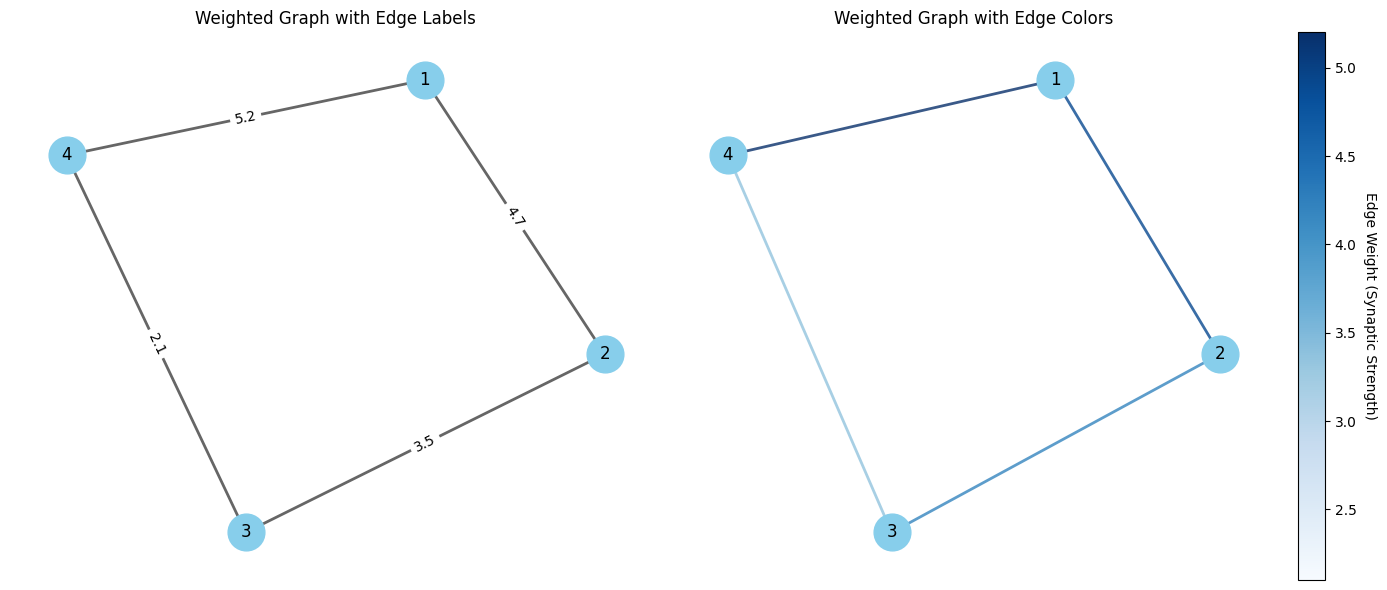

Edge weights:
  (1, 2): 4.7
  (1, 4): 5.2
  (2, 3): 3.5
  (3, 4): 2.1


In [4]:
# Create a weighted graph
G_weighted = nx.Graph()
G_weighted.add_edge(1, 2, weight=4.7)
G_weighted.add_edge(2, 3, weight=3.5)
G_weighted.add_edge(3, 4, weight=2.1)
G_weighted.add_edge(4, 1, weight=5.2)

# Define positions for consistent visualization
pos = nx.spring_layout(G_weighted, seed=42)

# Create two subplots for different weight representations
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Method 1: Edge labels showing weights
nx.draw_networkx_nodes(G_weighted, pos, node_color='skyblue', node_size=700, ax=axes[0])
nx.draw_networkx_edges(G_weighted, pos, ax=axes[0], width=2, alpha=0.6)
nx.draw_networkx_labels(G_weighted, pos, font_size=12, ax=axes[0])
edge_labels = nx.get_edge_attributes(G_weighted, 'weight')
nx.draw_networkx_edge_labels(G_weighted, pos, edge_labels, font_size=10, ax=axes[0])
axes[0].set_title("Weighted Graph with Edge Labels")
axes[0].axis('off')

# Method 2: Edge colors representing weights
# Extract weights for color mapping
weights = [G_weighted[u][v]['weight'] for u, v in G_weighted.edges()]
weights_normalized = np.array(weights) / max(weights)  # Normalize to [0, 1]

nx.draw_networkx_nodes(G_weighted, pos, node_color='skyblue', node_size=700, ax=axes[1])
nx.draw_networkx_edges(G_weighted, pos, ax=axes[1], width=2, alpha=0.8,
                       edge_color=weights_normalized, edge_cmap=plt.cm.Blues,
                       edge_vmin=0, edge_vmax=1)
nx.draw_networkx_labels(G_weighted, pos, font_size=12, ax=axes[1])
axes[1].set_title("Weighted Graph with Edge Colors")
axes[1].axis('off')

# Add a colorbar
sm = plt.cm.ScalarMappable(cmap=plt.cm.Blues, norm=plt.Normalize(vmin=min(weights), vmax=max(weights)))
sm.set_array([])
cbar = plt.colorbar(sm, ax=axes[1], orientation='vertical', fraction=0.046, pad=0.04)
cbar.set_label('Edge Weight (Synaptic Strength)', rotation=270, labelpad=15)

plt.tight_layout()
plt.show()

print("Edge weights:")
for edge, weight in edge_labels.items():
    print(f"  {edge}: {weight}")

### Simple vs. Non-simple Graphs

A **simple graph** has two restrictions:
1. No **loops**: An edge cannot connect a node to itself
2. No **multiple edges**: There can be at most one edge between any two nodes

A **non-simple graph** (or multigraph) allows loops and/or multiple edges between the same pair of nodes.

**In neuroscience:**
Real neural circuits are typically simple: a neuron doesn't form multiple independent synapses with another neuron (synapses are treated as a single connection). However, self-loops (recurrent connections where a neuron connects to itself) do occur biologically, so non-simple graphs can be relevant in certain contexts.

For this series, we focus on simple graphs, but it's good to know the distinction.

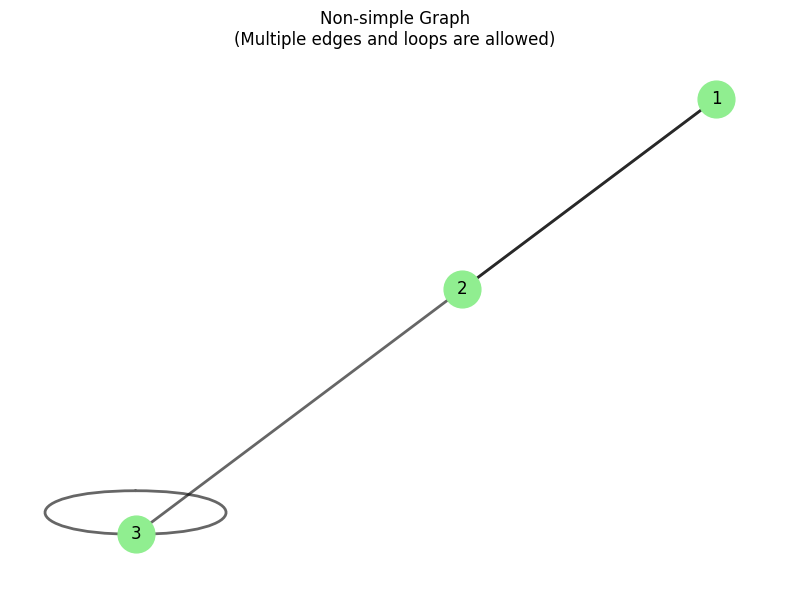

Number of edges between nodes 1 and 2: 2
Number of edges from node 3 to itself: 1


In [5]:
# Create a non-simple graph (multigraph allows parallel edges and loops)
G_non_simple = nx.MultiGraph()
G_non_simple.add_edge(1, 2)
G_non_simple.add_edge(1, 2)  # Parallel edge between 1 and 2
G_non_simple.add_edge(2, 3)
G_non_simple.add_edge(3, 3)  # Loop: node 3 connected to itself

# Visualize
pos = nx.spring_layout(G_non_simple, seed=42)
fig, ax = plt.subplots(figsize=(8, 6))

nx.draw_networkx_nodes(G_non_simple, pos, node_color='lightgreen', node_size=700, ax=ax)
nx.draw_networkx_edges(G_non_simple, pos, ax=ax, width=2, alpha=0.6)
nx.draw_networkx_labels(G_non_simple, pos, font_size=12, ax=ax)
ax.set_title("Non-simple Graph\n(Multiple edges and loops are allowed)")
ax.axis('off')

plt.tight_layout()
plt.show()

print(f"Number of edges between nodes 1 and 2: {G_non_simple.number_of_edges(1, 2)}")
print(f"Number of edges from node 3 to itself: {G_non_simple.number_of_edges(3, 3)}")

---

## Key Concepts in Graph Theory

Now that you understand the types of graphs, let's introduce some fundamental concepts used throughout graph analysis.

### Degree

The **degree** of a node is the number of edges connected to it.

In an **undirected graph**, this is straightforward: count all edges touching the node.

In a **directed graph**, we distinguish:
- **In-degree**: Number of edges coming *into* the node
- **Out-degree**: Number of edges going *out* from the node

**In neuroscience:**
- **Out-degree** = number of neurons this neuron projects to (its axonal targets)
- **In-degree** = number of neurons that project to this neuron (its dendritic inputs)

Neurons with high in-degree are **integrators** (they receive information from many sources). Neurons with high out-degree are **broadcasters** (they send information to many targets). Hub neurons (high degree in both directions) are crucial for network communication.

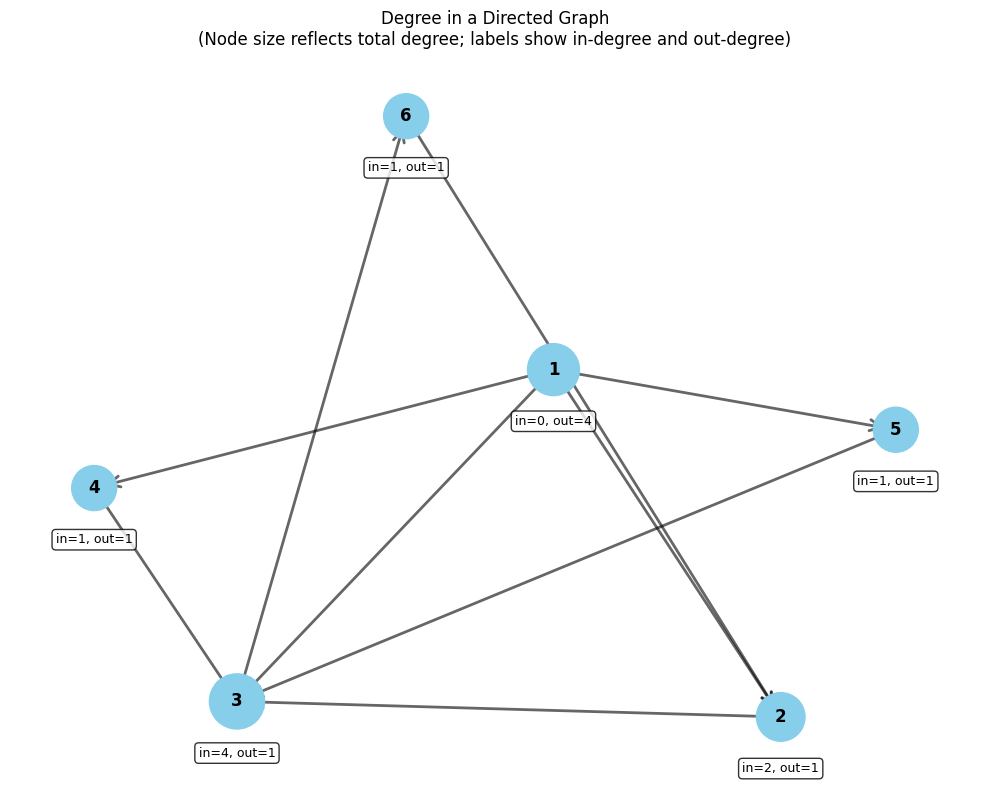


Degree Analysis:
  Node 1: in-degree=0, out-degree=4, total=4
  Node 2: in-degree=2, out-degree=1, total=3
  Node 3: in-degree=4, out-degree=1, total=5
  Node 4: in-degree=1, out-degree=1, total=2
  Node 5: in-degree=1, out-degree=1, total=2
  Node 6: in-degree=1, out-degree=1, total=2


In [6]:
# Create a directed graph with varying degrees
G_degree = nx.DiGraph()
G_degree.add_edges_from([
    (1, 2), (1, 3), (1, 4), (1, 5),  # Node 1 is a broadcaster (high out-degree)
    (2, 3), (3, 6),                  # Node 3 is an integrator (will have high in-degree)
    (4, 3), (5, 3), (6, 2)
])

# Compute degrees
in_degrees = dict(G_degree.in_degree())
out_degrees = dict(G_degree.out_degree())

# Visualize
pos = nx.spring_layout(G_degree, seed=42, k=2)
fig, ax = plt.subplots(figsize=(10, 8))

# Node size reflects total degree (in + out)
node_sizes = [700 * (1 + (in_degrees[node] + out_degrees[node]) / 4) for node in G_degree.nodes()]

nx.draw_networkx_nodes(G_degree, pos, node_color='skyblue', node_size=node_sizes, ax=ax)
nx.draw_networkx_edges(G_degree, pos, ax=ax, width=2, alpha=0.6, arrows=True, arrowsize=20, arrowstyle='->')
nx.draw_networkx_labels(G_degree, pos, font_size=12, font_weight='bold', ax=ax)

# Add degree information as text
for node in G_degree.nodes():
    x, y = pos[node]
    ax.text(x, y - 0.15, f"in={in_degrees[node]}, out={out_degrees[node]}",
           fontsize=9, ha='center', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax.set_title("Degree in a Directed Graph\n(Node size reflects total degree; labels show in-degree and out-degree)")
ax.axis('off')

plt.tight_layout()
plt.show()

print("\nDegree Analysis:")
for node in sorted(G_degree.nodes()):
    print(f"  Node {node}: in-degree={in_degrees[node]}, out-degree={out_degrees[node]}, total={in_degrees[node] + out_degrees[node]}")

### Path

A **path** is a sequence of nodes where each adjacent pair is connected by an edge. The **length** of a path is the number of edges in it.

For example, in the graph above, one path from node 1 to node 6 is: 1 → 3 → 6 (length 2). Another path is: 1 → 2 → 3 → 6 (length 3).

**In neuroscience:**
Paths represent communication routes through the network. The shortest path between two neurons tells you the minimum number of synaptic steps required for one to influence the other. This is crucial for understanding information flow in neural circuits.

### Cycle

A **cycle** is a path that starts and ends at the same node, without repeating any other nodes or edges.

In the graph above, one cycle is: 1 → 3 → 2 → (back to 1, if there were an edge from 2 to 1). Another is: 2 → 3 → 2 (a 2-node cycle).

**In neuroscience:**
Cycles represent **feedback loops**, which are essential for neural computation. Recurrent connections allow neurons to maintain information over time and create oscillations. Feedback loops are ubiquitous in the brain and are crucial for working memory, attention, and oscillatory rhythms.

### Connected Graph

A graph is **connected** if there is a path between every pair of nodes.

In a **directed graph**, we distinguish:
- **Strongly connected**: There's a directed path from every node to every other node
- **Weakly connected**: If we ignore edge directions, the graph is connected

**In neuroscience:**
A connected neural circuit means information can, in principle, propagate from any neuron to any other. However, most real neural systems are not globally connected; instead, they consist of **connected components**—clusters of neurons that are internally connected but may be disconnected from other clusters. This modular structure is actually an advantage: it allows specialization and reduces wiring costs.

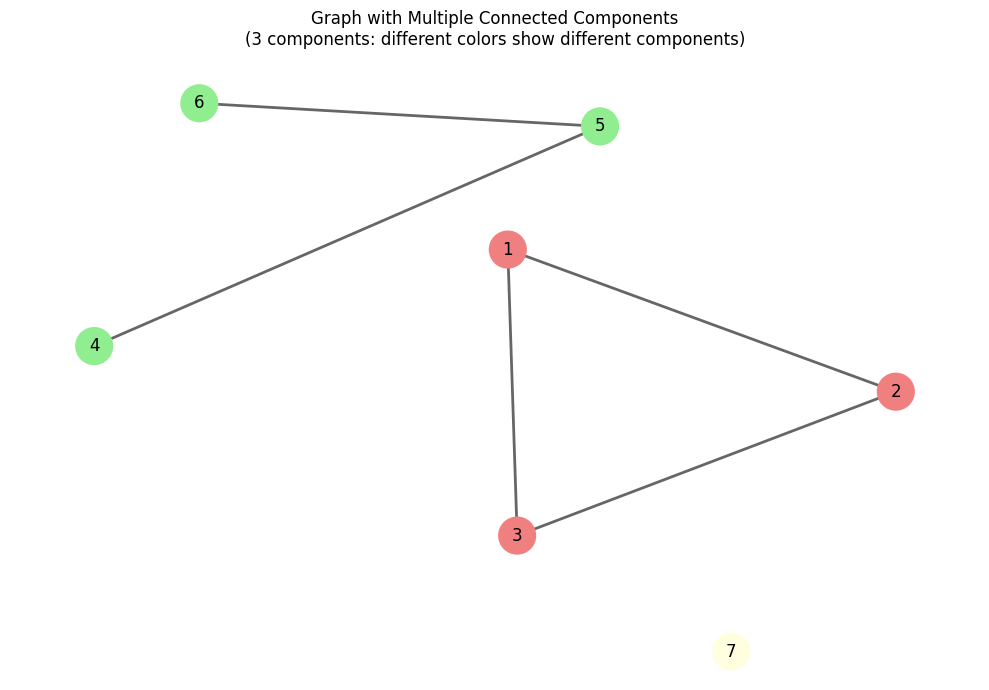

Number of connected components: 3
  Component 1: [1, 2, 3]
  Component 2: [4, 5, 6]
  Component 3: [7]


In [7]:
# Create a graph with multiple connected components
G_components = nx.Graph()

# Component 1
G_components.add_edges_from([(1, 2), (2, 3), (3, 1)])  # Triangle

# Component 2
G_components.add_edges_from([(4, 5), (5, 6)])  # Chain

# Isolated node
G_components.add_node(7)

# Analyze connectivity
num_components = nx.number_connected_components(G_components)
components = list(nx.connected_components(G_components))

# Visualize
pos = nx.spring_layout(G_components, seed=42, k=2)
fig, ax = plt.subplots(figsize=(10, 7))

# Color nodes by component
node_colors = []
color_map = ['lightcoral', 'lightgreen', 'lightyellow']
for node in G_components.nodes():
    for i, comp in enumerate(components):
        if node in comp:
            node_colors.append(color_map[i % len(color_map)])
            break

nx.draw_networkx_nodes(G_components, pos, node_color=node_colors, node_size=700, ax=ax)
nx.draw_networkx_edges(G_components, pos, ax=ax, width=2, alpha=0.6)
nx.draw_networkx_labels(G_components, pos, font_size=12, ax=ax)

ax.set_title(f"Graph with Multiple Connected Components\n({num_components} components: different colors show different components)")
ax.axis('off')

plt.tight_layout()
plt.show()

print(f"Number of connected components: {num_components}")
for i, comp in enumerate(components):
    print(f"  Component {i+1}: {sorted(comp)}")

### Subgraph

A **subgraph** is a graph formed by selecting a subset of nodes and edges from a larger graph. More precisely, it includes a subset of the original nodes and all edges whose endpoints are in that subset.

**In neuroscience:**
Subgraphs represent neural circuits within a larger brain region. For example, a visual cortex circuit is a subgraph of the entire mammalian brain. Analyzing subgraphs helps us understand how local circuits are organized and how they contribute to larger-scale function.

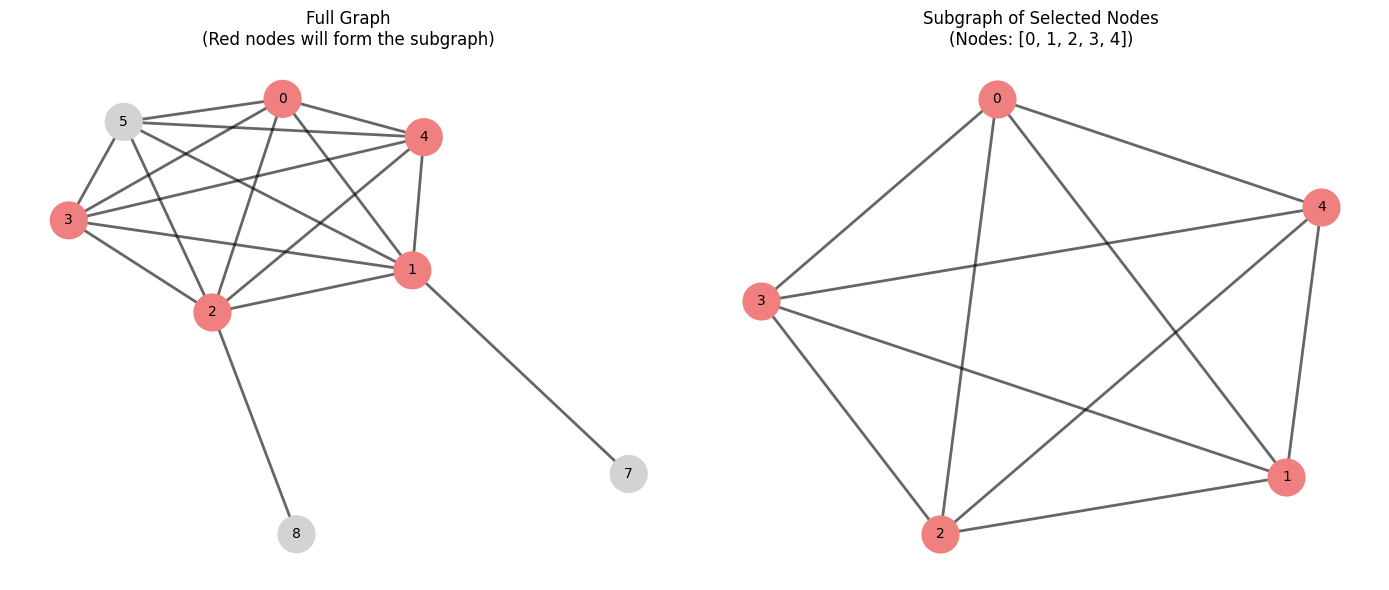

Full graph: 8 nodes, 17 edges
Subgraph: 5 nodes, 10 edges


In [8]:
# Create a full graph and extract a subgraph
G_full = nx.complete_graph(6)  # A complete graph on 6 nodes
G_full.add_edges_from([(1, 7), (2, 8)])  # Add two external nodes

# Extract a subgraph containing only nodes 0, 1, 2, 3, 4
subgraph_nodes = [0, 1, 2, 3, 4]
G_subgraph = G_full.subgraph(subgraph_nodes).copy()

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Full graph
pos_full = nx.spring_layout(G_full, seed=42, k=2)
node_colors_full = ['lightcoral' if node in subgraph_nodes else 'lightgray' for node in G_full.nodes()]
nx.draw_networkx_nodes(G_full, pos_full, node_color=node_colors_full, node_size=700, ax=axes[0])
nx.draw_networkx_edges(G_full, pos_full, ax=axes[0], width=2, alpha=0.6)
nx.draw_networkx_labels(G_full, pos_full, font_size=10, ax=axes[0])
axes[0].set_title("Full Graph\n(Red nodes will form the subgraph)")
axes[0].axis('off')

# Subgraph
pos_sub = nx.spring_layout(G_subgraph, seed=42, k=2)
nx.draw_networkx_nodes(G_subgraph, pos_sub, node_color='lightcoral', node_size=700, ax=axes[1])
nx.draw_networkx_edges(G_subgraph, pos_sub, ax=axes[1], width=2, alpha=0.6)
nx.draw_networkx_labels(G_subgraph, pos_sub, font_size=10, ax=axes[1])
axes[1].set_title(f"Subgraph of Selected Nodes\n(Nodes: {subgraph_nodes})")
axes[1].axis('off')

plt.tight_layout()
plt.show()

print(f"Full graph: {G_full.number_of_nodes()} nodes, {G_full.number_of_edges()} edges")
print(f"Subgraph: {G_subgraph.number_of_nodes()} nodes, {G_subgraph.number_of_edges()} edges")

---

## Biological Network Properties

Now that you understand the basic concepts, let's preview the properties we'll focus on throughout this series. These properties distinguish biological neural networks from random graphs.

| Property | Description | Biological Relevance |
|----------|-------------|---------------------|
| **Hierarchical** | Nodes are organized in levels; information flows from low (input) to high (output) levels | Brain regions are hierarchically organized (sensory → associative → motor) |
| **Modular** | Graph decomposes into clusters (modules) with many internal edges but few inter-module edges | Functional specialization; efficient learning; robustness |
| **Directional** | Edges have direction reflecting information or resource flow | Synaptic transmission is unidirectional (from presynaptic to postsynaptic) |
| **Redundant** | Multiple pathways exist between important nodes; removing a single connection doesn't isolate the network | Robustness against neuron loss or synaptic failure |
| **Resource-efficient** | Network structure reflects constraints (physical space, metabolic budget) | Brains are metabolically expensive; sparsity reduces costs |
| **Weighted** | Edges carry weights representing importance or capacity | Synaptic strength varies; learning changes weights |

Throughout this series, we'll explore how to measure these properties (Notebook 2), how different generative models capture them (Notebooks 3-4), and how to sculpt raw graph generators into realistic networks through pruning (Notebooks 5-6).

---

## A Preview: The `analyze_graph()` Helper Function

In Notebook 2, we'll deeply explore how to measure graph properties. For now, let's introduce a helper function you'll use throughout the series: `analyze_graph()`. This function computes basic metrics and will be expanded in future notebooks.

**Spoiler**: You'll use this function constantly to quantify how well your generated networks match biological criteria.

In [9]:
def analyze_graph(G, name="Graph"):
    """Compute and print key graph metrics.

    We'll use this helper function throughout the series to quantify
    how well generated networks match our biological criteria.

    Parameters:
    -----------
    G : networkx.Graph
        The graph to analyze
    name : str
        A label for the output (e.g., 'Small-world network')

    Returns:
    --------
    dict : Dictionary with keys 'name', 'n', 'edges', 'density'
    """
    n = G.number_of_nodes()
    e = G.number_of_edges()

    # Calculate maximum possible edges (depends on graph type)
    if G.is_directed():
        max_edges = n * (n - 1)
    else:
        max_edges = n * (n - 1) / 2

    density = e / max_edges if max_edges > 0 else 0
    avg_degree = sum(dict(G.degree()).values()) / n if n > 0 else 0

    print(f"\n--- {name} ---")
    print(f"Nodes: {n}, Edges: {e}")
    print(f"Density (fraction of possible edges): {density:.4f}")
    print(f"Average Degree: {avg_degree:.2f}")

    return {
        "name": name,
        "n": n,
        "edges": e,
        "density": density,
        "avg_degree": avg_degree
    }

print("Helper function defined: analyze_graph()")

Helper function defined: analyze_graph()


Let's test this function on the example graphs we've created:

In [10]:
# Analyze the example graphs
results = []
results.append(analyze_graph(G_undirected, "Undirected Graph"))
results.append(analyze_graph(G_directed, "Directed Graph"))
results.append(analyze_graph(G_weighted, "Weighted Graph"))
results.append(analyze_graph(G_non_simple, "Non-simple Graph (Multigraph)"))
results.append(analyze_graph(G_degree, "Degree Example Graph"))

print("\n" + "="*60)
print("Summary of example graphs:")
print("="*60)
for result in results:
    print(f"  {result['name']:30s}: Nodes={result['n']:2d}, Edges={result['edges']:2d}, Density={result['density']:.3f}")


--- Undirected Graph ---
Nodes: 4, Edges: 4
Density (fraction of possible edges): 0.6667
Average Degree: 2.00

--- Directed Graph ---
Nodes: 4, Edges: 4
Density (fraction of possible edges): 0.3333
Average Degree: 2.00

--- Weighted Graph ---
Nodes: 4, Edges: 4
Density (fraction of possible edges): 0.6667
Average Degree: 2.00

--- Non-simple Graph (Multigraph) ---
Nodes: 3, Edges: 4
Density (fraction of possible edges): 1.3333
Average Degree: 2.67

--- Degree Example Graph ---
Nodes: 6, Edges: 9
Density (fraction of possible edges): 0.3000
Average Degree: 3.00

Summary of example graphs:
  Undirected Graph              : Nodes= 4, Edges= 4, Density=0.667
  Directed Graph                : Nodes= 4, Edges= 4, Density=0.333
  Weighted Graph                : Nodes= 4, Edges= 4, Density=0.667
  Non-simple Graph (Multigraph) : Nodes= 3, Edges= 4, Density=1.333
  Degree Example Graph          : Nodes= 6, Edges= 9, Density=0.300


---

## Key Takeaways

### What You've Learned

1. **Graphs model networks**: A graph is a mathematical structure consisting of nodes (objects) and edges (connections). Neural networks are graphs.

2. **Multiple graph types exist**, each suited to different problems:
   - **Undirected vs. Directed**: Are relationships symmetric or asymmetric? Synaptic connectivity is directed.
   - **Weighted vs. Unweighted**: Do connections have variable importance? Synapses have variable strength (weight).
   - **Simple vs. Non-simple**: Can nodes connect to themselves or to each other multiple times? Usually not in neural networks.

3. **Key graph concepts** are the vocabulary for analyzing networks:
   - **Degree**: How many connections does a node have? (High-degree nodes are hubs.)
   - **Path**: How do signals travel through the network?
   - **Cycle**: Are there feedback loops?
   - **Connected component**: Do all nodes belong to a single connected group?
   - **Subgraph**: How do local circuits organize?

4. **Biological networks have specific properties**:
   - Hierarchical, modular, directional, redundant, resource-efficient, and weighted
   - These properties emerge from developmental and functional constraints
   - We'll measure and generate these properties in subsequent notebooks

5. **Graph analysis requires tools**: The `analyze_graph()` function is our starting point for quantifying network properties. We'll expand it throughout the series.

---

## What's Next?

You now have the conceptual foundation. In **Notebook 2 — Analyzing Graph Features**, we'll:

1. **Expand `analyze_graph()`** to compute clustering coefficient, average shortest path length, and degree distribution
2. **Define small-world networks**: Why are they biologically important?
3. **Compute centrality measures**: Which nodes are most important? (Degree centrality, betweenness, closeness)
4. **Detect communities**: How do we identify functional modules in a network?

These metrics are essential for evaluating whether a generated network is biologically plausible.

---

### Further Reading

If you want to dive deeper into any topic:

- **Graph Theory Fundamentals**: Diestel, R. *Graph Theory* (Springer) — the standard reference
- **Networks in Biology**: Newman, M. E. J. (2003). "The structure and function of complex networks." *SIAM Review*, 45(2), 167-256
- **Brain Connectivity**: Bullmore, E., & Sporns, O. (2009). "Complex brain networks: graph theoretical analysis of structural and functional systems." *Nature Reviews Neuroscience*, 10(3), 186-198

---

In [11]:
# Final checkpoint
print("\n" + "="*60)
print("Notebook 1 Complete!")
print("="*60)
print("\nYou now understand:")
print("  ✓ What graphs are and why they matter for neuroscience")
print("  ✓ The major types of graphs (directed, weighted, simple, etc.)")
print("  ✓ Key concepts (degree, path, cycle, connectivity, subgraphs)")
print("  ✓ Biological properties that distinguish neural networks")
print("  ✓ How to analyze graphs with basic metrics")
print("\nNext: Notebook 2 — Analyzing Graph Features")
print("="*60)


Notebook 1 Complete!

You now understand:
  ✓ What graphs are and why they matter for neuroscience
  ✓ The major types of graphs (directed, weighted, simple, etc.)
  ✓ Key concepts (degree, path, cycle, connectivity, subgraphs)
  ✓ Biological properties that distinguish neural networks
  ✓ How to analyze graphs with basic metrics

Next: Notebook 2 — Analyzing Graph Features
